## Import Packages

In [22]:
import os
import yaml
import math
import numpy as np
import scanpy as sc
import humanfriendly

import matplotlib
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

## Parameters

In [3]:
# this cell is tagged `parameters` and will be overridden by papermill
sample_name = "1973_HD1915_7xNK_FB_HTO"
path_h5ad = "/test/hashtag/1973_HD1915_7xNK_FB_HTO.h5ad"
path_report = "/test/hashtag/run_report.yaml"
path_read_mtx = "/test/hashtag/reads/matrix.mtx.gz"
path_outdir = "/test/hashtag"

## Run Report

In [8]:
!cat $path_report

Date: 2025-04-22
Running time: 8.0 minutes, 59.34 seconds
CITE-seq-Count Version: 1.4.5
Reads processed: 1250000
Percentage mapped: 96
Percentage unmapped: 4
Uncorrected cells: 0
Correction:
	Cell barcodes collapsing threshold: 1
	Cell barcodes corrected: 3662
	UMI collapsing threshold: 1
	UMIs corrected: 2368
Run parameters:
	Read1_paths: /cromwell-executions/Hashtag/4308a24f-6168-452c-bc0a-00f5587ecf96/call-Preprocess/Preprocess/fb88becb-27ef-4f21-860d-21f76ed4504e/call-CiteSeqCount/inputs/-1040196411/R1.fastq.gz
	Read2_paths: /cromwell-executions/Hashtag/4308a24f-6168-452c-bc0a-00f5587ecf96/call-Preprocess/Preprocess/fb88becb-27ef-4f21-860d-21f76ed4504e/call-CiteSeqCount/inputs/1457819526/R2.fastq.gz
	Cell barcode:
		First position: 1
		Last position: 16
	UMI barcode:
		First position: 17
		Last position: 28
	Expected cells: 0
	Tags max errors: 2
	Start trim: 10


## Load AnnData

In [10]:
adata = sc.read_h5ad(path_h5ad)
print(f"Cells: {adata.n_obs}, Barcodes: {adata.n_vars}")

print(f"Counts: {adata.X.sum()}")
display(adata.to_df().head())

print("Classification Overview")
df_stats = adata.obs.groupby("hash_id").size()
display(df_stats)

Cells: 6794880, Barcodes: 8
Counts: 968594


,B0310-CCGATTGTAACAGAC,B0302-GGTCGAGAGCATTCA,B0303-CTTGCCGCATGTCAT,B0304-AAAGCATTCTTCACG,B0305-CTTTGTCTTTGTGAG,B0306-TATGCTGCCACGGTA,B0309-TGCCTATGAAACAAG,B0308-TATAGAACGCCAGGC
cell_barcodes,,,,,,,,
ATGCCTCTCACACACG,0,0,0,0,0,0,0,0
TGAGGGAAGGCTACGG,0,0,0,0,0,0,0,0
ATCGGCGGTGGGTATG,0,0,0,0,0,0,0,0
TAGGTACTCTTGTCGT,0,0,0,0,0,0,0,0
GAGTTTGAGAGAGTGA,0,0,0,0,0,0,0,0


Classification Overview


/tmp/ipykernel_2250999/1001004742.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = adata.obs.groupby("hash_id").size()


hash_id
B0302         25383
B0303         13055
B0304          9386
B0305          3743
B0306          5278
B0308         13259
B0309          8329
B0310          5808
Doublet       22317
Negative    6688322
dtype: int64

## Load Read Counts

In [28]:
with open(path_report, "rt") as fin:
    # report file contains tabs
    # run_report = yaml.load(fin, Loader=yaml.FullLoader)
    run_report = fin.read().replace("\t", "  ")
    run_report = yaml.load(run_report, Loader=yaml.FullLoader)

# add reads
mtx = scipy.io.mmread(path_read_mtx)
adata.layers["reads"] = mtx.T.tocsr()[:, :-1]
adata.obs.loc[:, "unmapped_reads"] = mtx.T.toarray()[:, -1]
adata.obs.loc[:, "total_reads"] = adata.layers["reads"].sum(axis=1).A1
adata.obs.loc[:, "total_umis"] = adata.X.sum(axis=1).A1
reads_mapped = adata.layers["reads"].sum() / run_report["Reads processed"] * 100

print(f"Counts: {adata.X.sum()}")
print(f"Reads: {adata.layers['reads'].sum()}")
print(f"Reads mapped: {reads_mapped:.1f}%")

Counts: 968594
Reads: 1182878
Reads mapped: 94.6%


## QC

In [29]:
adata.var["total_reads"] = adata.layers["reads"].sum(axis=0).A1
adata.var["total_counts"] = adata.X.sum(axis=0).A1
zero_counts = adata.var["total_counts"] == 0

print(f"Total reads: {humanfriendly.format_number(adata.var['total_reads'].sum())}")
display(adata.var[["total_reads"]])
print("--" * 20)
print(f"Total counts: {humanfriendly.format_number(adata.var['total_counts'].sum())}")
display(adata.var[["total_counts"]])
print("--" * 20)
print(f"Zero counts: {zero_counts.sum()} ({zero_counts.mean():.1%})")

Total reads: 1,182,878


,total_reads
B0310-CCGATTGTAACAGAC,107982
B0302-GGTCGAGAGCATTCA,284046
B0303-CTTGCCGCATGTCAT,227419
B0304-AAAGCATTCTTCACG,138846
B0305-CTTTGTCTTTGTGAG,75630
B0306-TATGCTGCCACGGTA,63595
B0309-TGCCTATGAAACAAG,118976
B0308-TATAGAACGCCAGGC,166384


----------------------------------------
Total counts: 968,594


,total_counts
B0310-CCGATTGTAACAGAC,88236
B0302-GGTCGAGAGCATTCA,232161
B0303-CTTGCCGCATGTCAT,186217
B0304-AAAGCATTCTTCACG,113940
B0305-CTTTGTCTTTGTGAG,62019
B0306-TATGCTGCCACGGTA,52246
B0309-TGCCTATGAAACAAG,97494
B0308-TATAGAACGCCAGGC,136281


----------------------------------------
Zero counts: 0 (0.0%)


## Classification

### Pie Chart

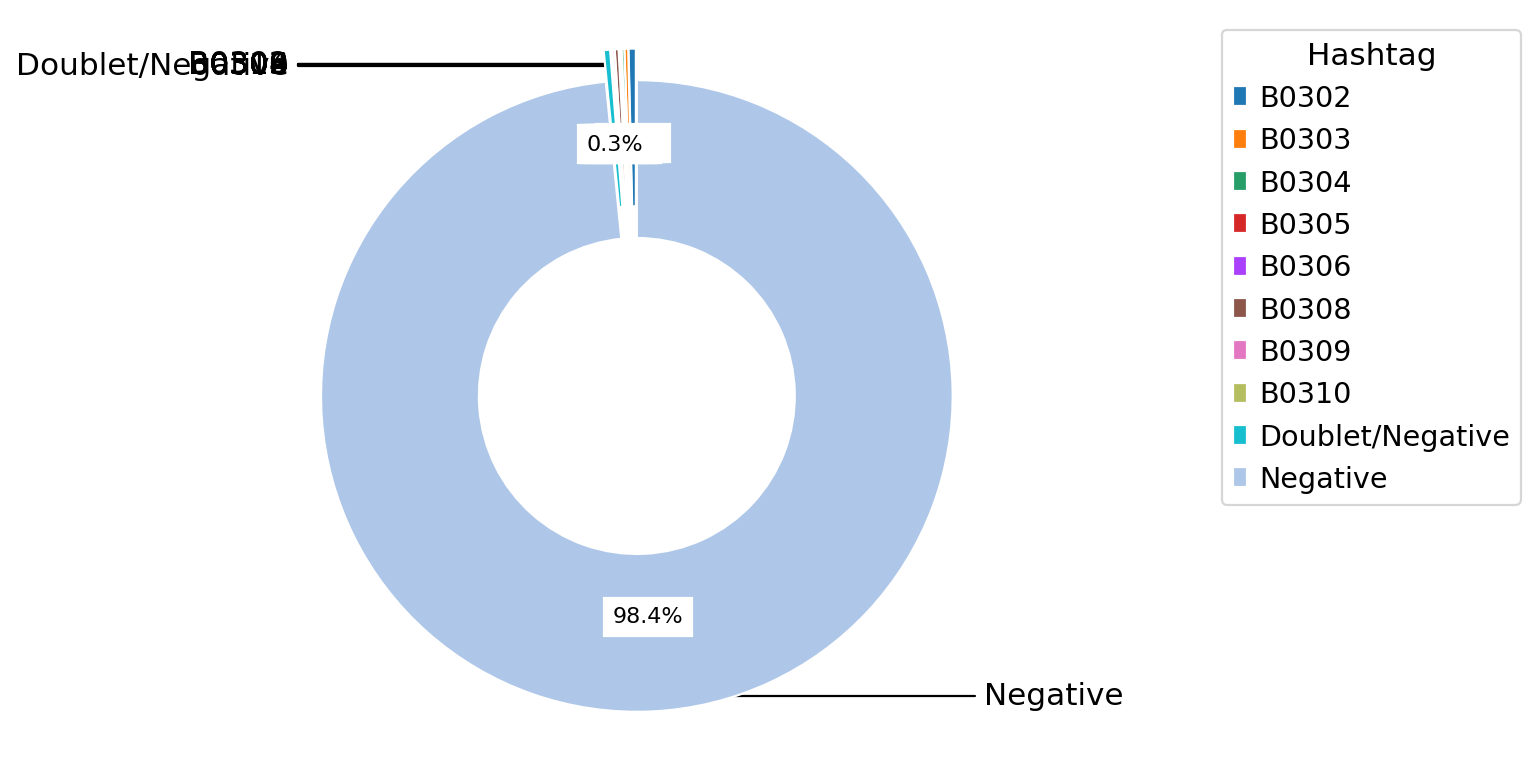

In [30]:
labels = [label if label != "Doublet" else "Doublet/Negative" for label in df_stats.index]

fig = plt.figure(figsize=(6,6), facecolor="white")
ax = fig.add_subplot(111)

def func_autopct(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:,d})".format(pct, absolute)

cmap = plt.get_cmap("tab20c")

wedges, _, autotexts = ax.pie(
    df_stats,
    explode=[0.05] * len(df_stats),
    wedgeprops=dict(width=0.5, edgecolor='w'),
    autopct='%1.1f%%',
    pctdistance=0.7,
    shadow=False,
    startangle=90,
    rotatelabels=True
)

kw = dict(arrowprops=dict(arrowstyle="-"), zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1) / 2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(
        labels[i], xy=(x, y), xytext=(1.1 * np.sign(x), y),
        horizontalalignment=horizontalalignment, **kw
    )

for i, autotext in enumerate(autotexts):
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_rotation(0)
    autotext.set_backgroundcolor("white")

ax.axis('equal')
ax.legend(
    wedges,
    labels,
    title="Hashtag",
    bbox_to_anchor=(1.2, 0.0, 0.5, 1)
)

plt.show()

## Read Counts

### Overall Stats

In [33]:
display(adata.to_df(layer="reads").sum(axis=1).describe().round(2))

count    6794880.00
mean           0.17
std            7.11
min            0.00
25%            0.00
50%            0.00
75%            0.00
max         5734.00
dtype: float64

In [34]:
percentile_95 = adata.obs["total_reads"].describe(percentiles=[0.95])["95%"]

print(f"Cells with more than 95th percentile ({percentile_95}) reads")
display(adata.to_df(layer="reads")[adata.obs["total_reads"] > percentile_95].sample(5, random_state=0))

Cells with more than 95th percentile (0.0) reads


,B0310-CCGATTGTAACAGAC,B0302-GGTCGAGAGCATTCA,B0303-CTTGCCGCATGTCAT,B0304-AAAGCATTCTTCACG,B0305-CTTTGTCTTTGTGAG,B0306-TATGCTGCCACGGTA,B0309-TGCCTATGAAACAAG,B0308-TATAGAACGCCAGGC
cell_barcodes,,,,,,,,
TCTAACTCAGGATTCT,1,12,2,0,0,0,0,2
GCAGCCAGTTAGAAGT,0,0,0,0,0,0,0,1
TCGATTTGTCCCGTGA,0,1,0,0,0,0,0,0
GAGAAATCAAAGTATG,0,0,1,0,0,0,0,0
TACCGGGCAAGAGGCT,1,7,0,259,0,1,1,2


### Histogram (sum of reads per hashtag)

In [40]:
adata.to_df("reads").melt().shape

(54359040, 2)

/tmp/ipykernel_2250999/1146337064.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


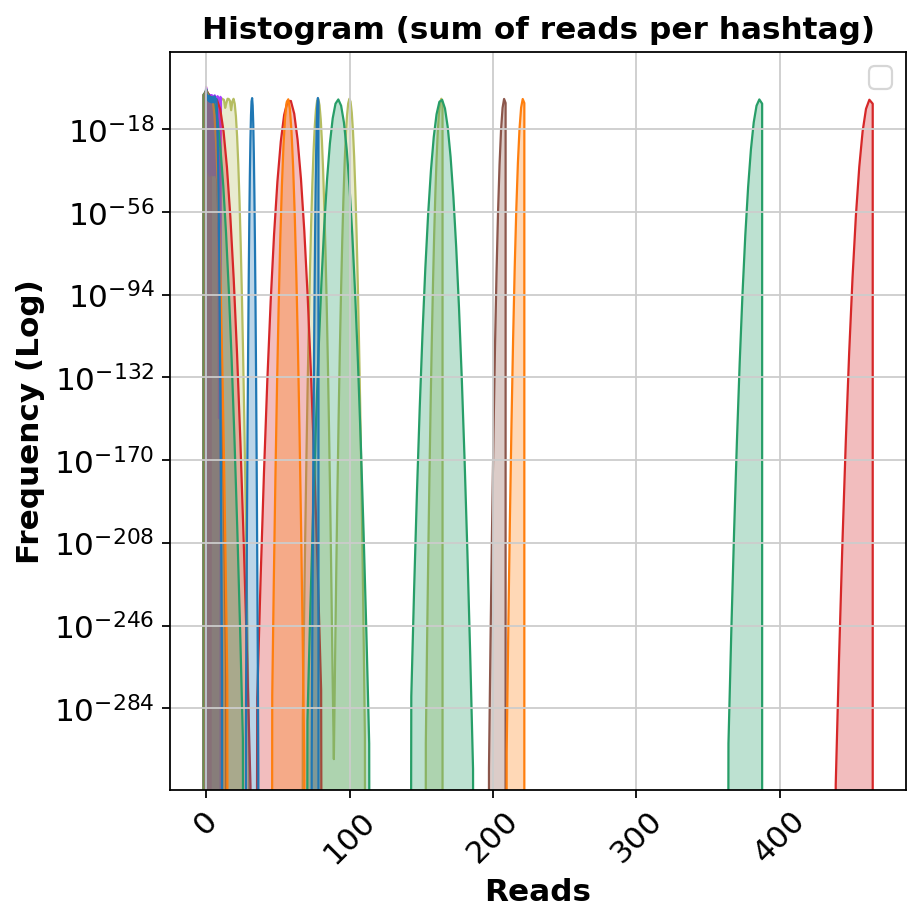

In [44]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")

nsample = min(100000, adata.shape[0] * adata.shape[1])
ax = sns.kdeplot(adata.to_df("reads").melt().sample(nsample), x="value", hue="variable", ax=ax, fill=True, alpha=0.3, common_norm=False)

ax.set_xlabel("Reads", fontweight="bold")
ax.set_ylabel("Frequency (Log)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.set_title("Histogram (sum of reads per hashtag)", fontweight="bold")
ax.legend()

plt.yscale("log")
plt.tight_layout()
plt.show()

### Unmapped

In [47]:
print("Top 10 unmapped reads")
adata.obs[["unmapped_reads", "total_umis"]].sort_values("unmapped_reads", ascending=False).head(10)

Top 10 unmapped reads


,unmapped_reads,total_umis
cell_barcodes,,
TATCAGGAGAAACTCA,298,4711
TCAGTGAAGCACTTTG,115,1644
CAGTTCCAGAAGAGCA,88,1647
CATACTTTCTCTCTTC,87,983
GTTGCTCGTGACGCCT,76,1128
TTACGCCAGTCTCTGA,73,987
TCGAACACAGTATACC,72,1159
CTACAGAAGACGCATG,70,1366
GAGTGTTAGTCATTGC,69,869


### Total vs. Unmapped Reads

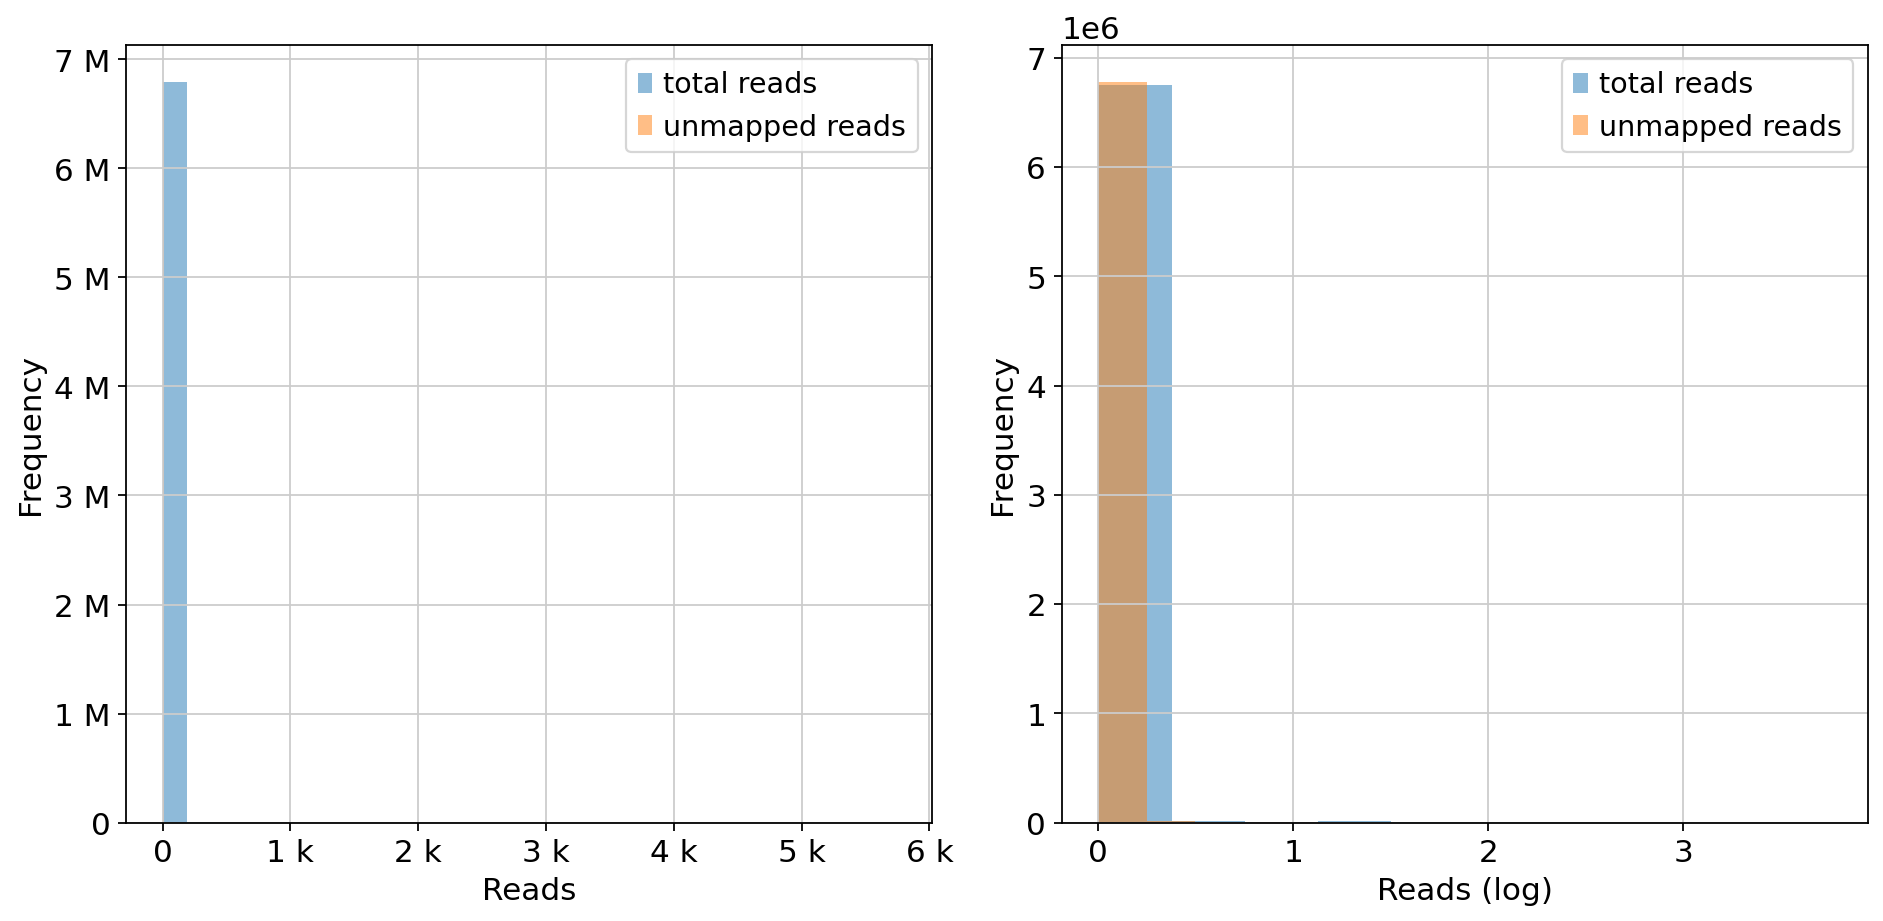

In [51]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6), facecolor="white")
ax = np.ravel(ax)

ax[0].hist(adata.obs["total_reads"], bins=30, label="total reads", alpha=0.5)
ax[0].hist(adata.obs["unmapped_reads"], bins=30, label="unmapped reads", alpha=0.5)

ax[0].set_xlabel("Reads")
ax[0].set_ylabel("Frequency")
ax[0].xaxis.set_major_formatter(matplotlib.ticker.EngFormatter())
ax[0].yaxis.set_major_formatter(matplotlib.ticker.EngFormatter())
ax[0].legend()

ax[1].hist(np.log10(adata.obs["total_reads"] + 1), label="total reads", alpha=0.5)
ax[1].hist(np.log10(adata.obs["unmapped_reads"] + 1), label="unmapped reads", alpha=0.5)

ax[1].set_xlabel("Reads (log)")
ax[1].set_ylabel("Frequency")
ax[1].legend()

plt.tight_layout()
plt.show()

## UMI Counts

### Histogram (sum of UMIs across hashtag)

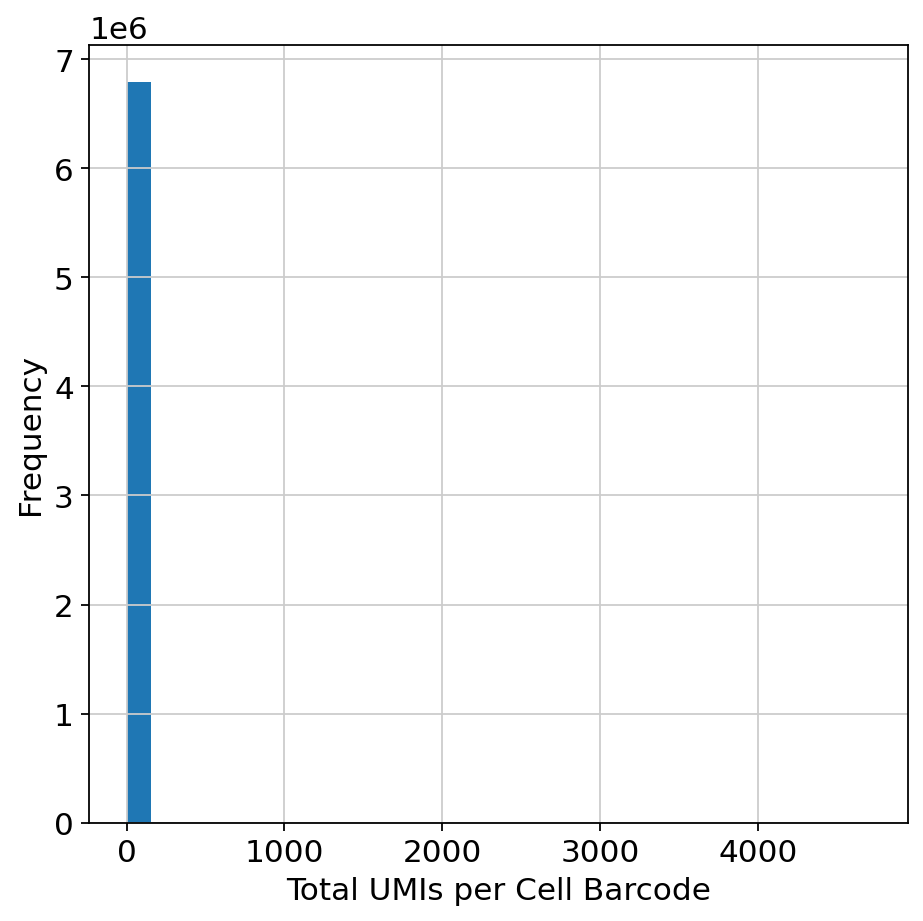

In [54]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")

ax.hist(adata.obs["total_umis"], bins=30)
ax.set_xlabel("Total UMIs per Cell Barcode")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [56]:
adata.to_df().describe().round(2)

,B0310-CCGATTGTAACAGAC,B0302-GGTCGAGAGCATTCA,B0303-CTTGCCGCATGTCAT,B0304-AAAGCATTCTTCACG,B0305-CTTTGTCTTTGTGAG,B0306-TATGCTGCCACGGTA,B0309-TGCCTATGAAACAAG,B0308-TATAGAACGCCAGGC
count,6794880.00,6794880.00,6794880.00,6794880.00,6794880.00,6794880.00,6794880.00,6794880.00
mean,0.01,0.03,0.03,0.02,0.01,0.01,0.01,0.02
std,1.37,2.12,2.89,1.40,0.94,0.87,1.35,2.42
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,726.00,1119.00,1237.00,724.00,525.00,394.00,948.00,4683.00


## Reads per UMI

### Calculate

In [57]:
avg_reads_per_umi= adata.obs["total_reads"].sum() / adata.obs["total_umis"].sum()
print(f"Average reads per UMI: {avg_reads_per_umi:.1f}")

Average reads per UMI: 1.2


### Histogram

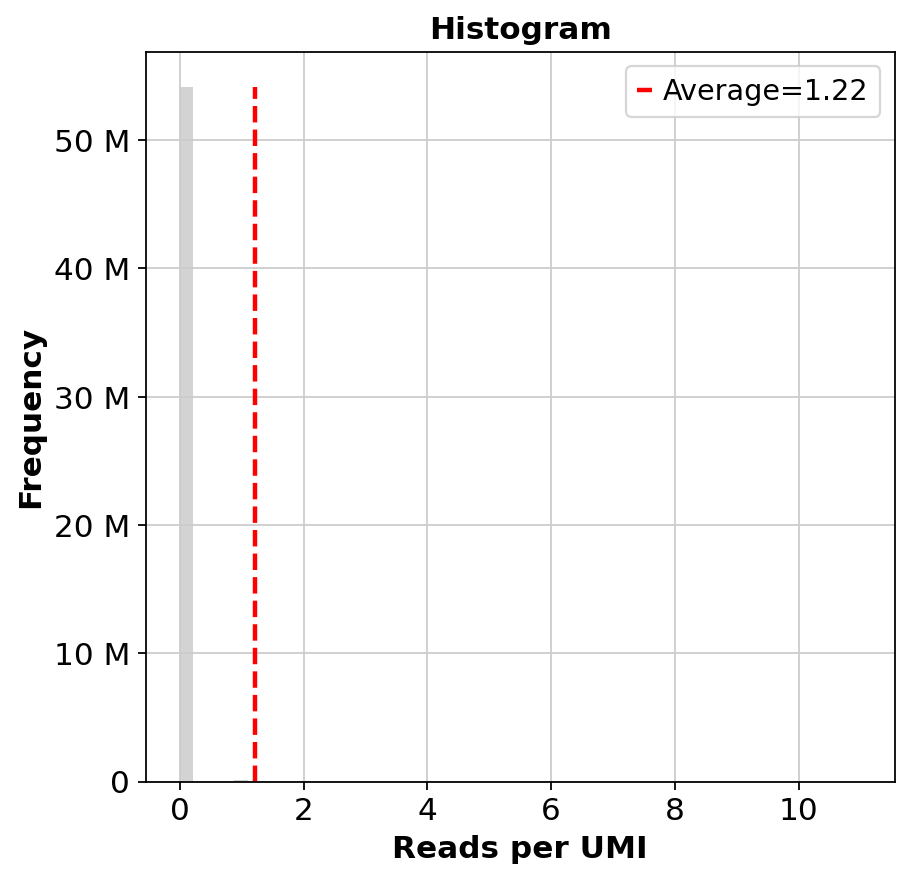

In [60]:
fig, ax = plt.subplots(figsize=(6,6), facecolor="white")
reads_per_umi = np.nan_to_num(adata.layers["reads"] / adata.X)
n, bins, _ = ax.hist(reads_per_umi.A1, bins=50, color="lightgray")
ax.vlines(
    x=avg_reads_per_umi,
    ymin=0, ymax=np.max(n),
    color="red", linestyle="--", lw=2,
    label=f"Average={avg_reads_per_umi:.2f}"
)

ax.set_xlabel("Reads per UMI", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
ax.yaxis.set_major_formatter(matplotlib.ticker.EngFormatter())
ax.set_title("Histogram", fontweight="bold")
ax.legend()

plt.show()

## UMI (one vs. rest)

- Ideally, the winning one shouldn't be winning by having less than e.g. 10 UMIs?
- Ideally, the losing ones should have UMIs close to zero.

### All

In [62]:
hashtags = sorted(list(set(adata.obs["hash_id"].unique()) - set(["Doublet", "Negative"])))


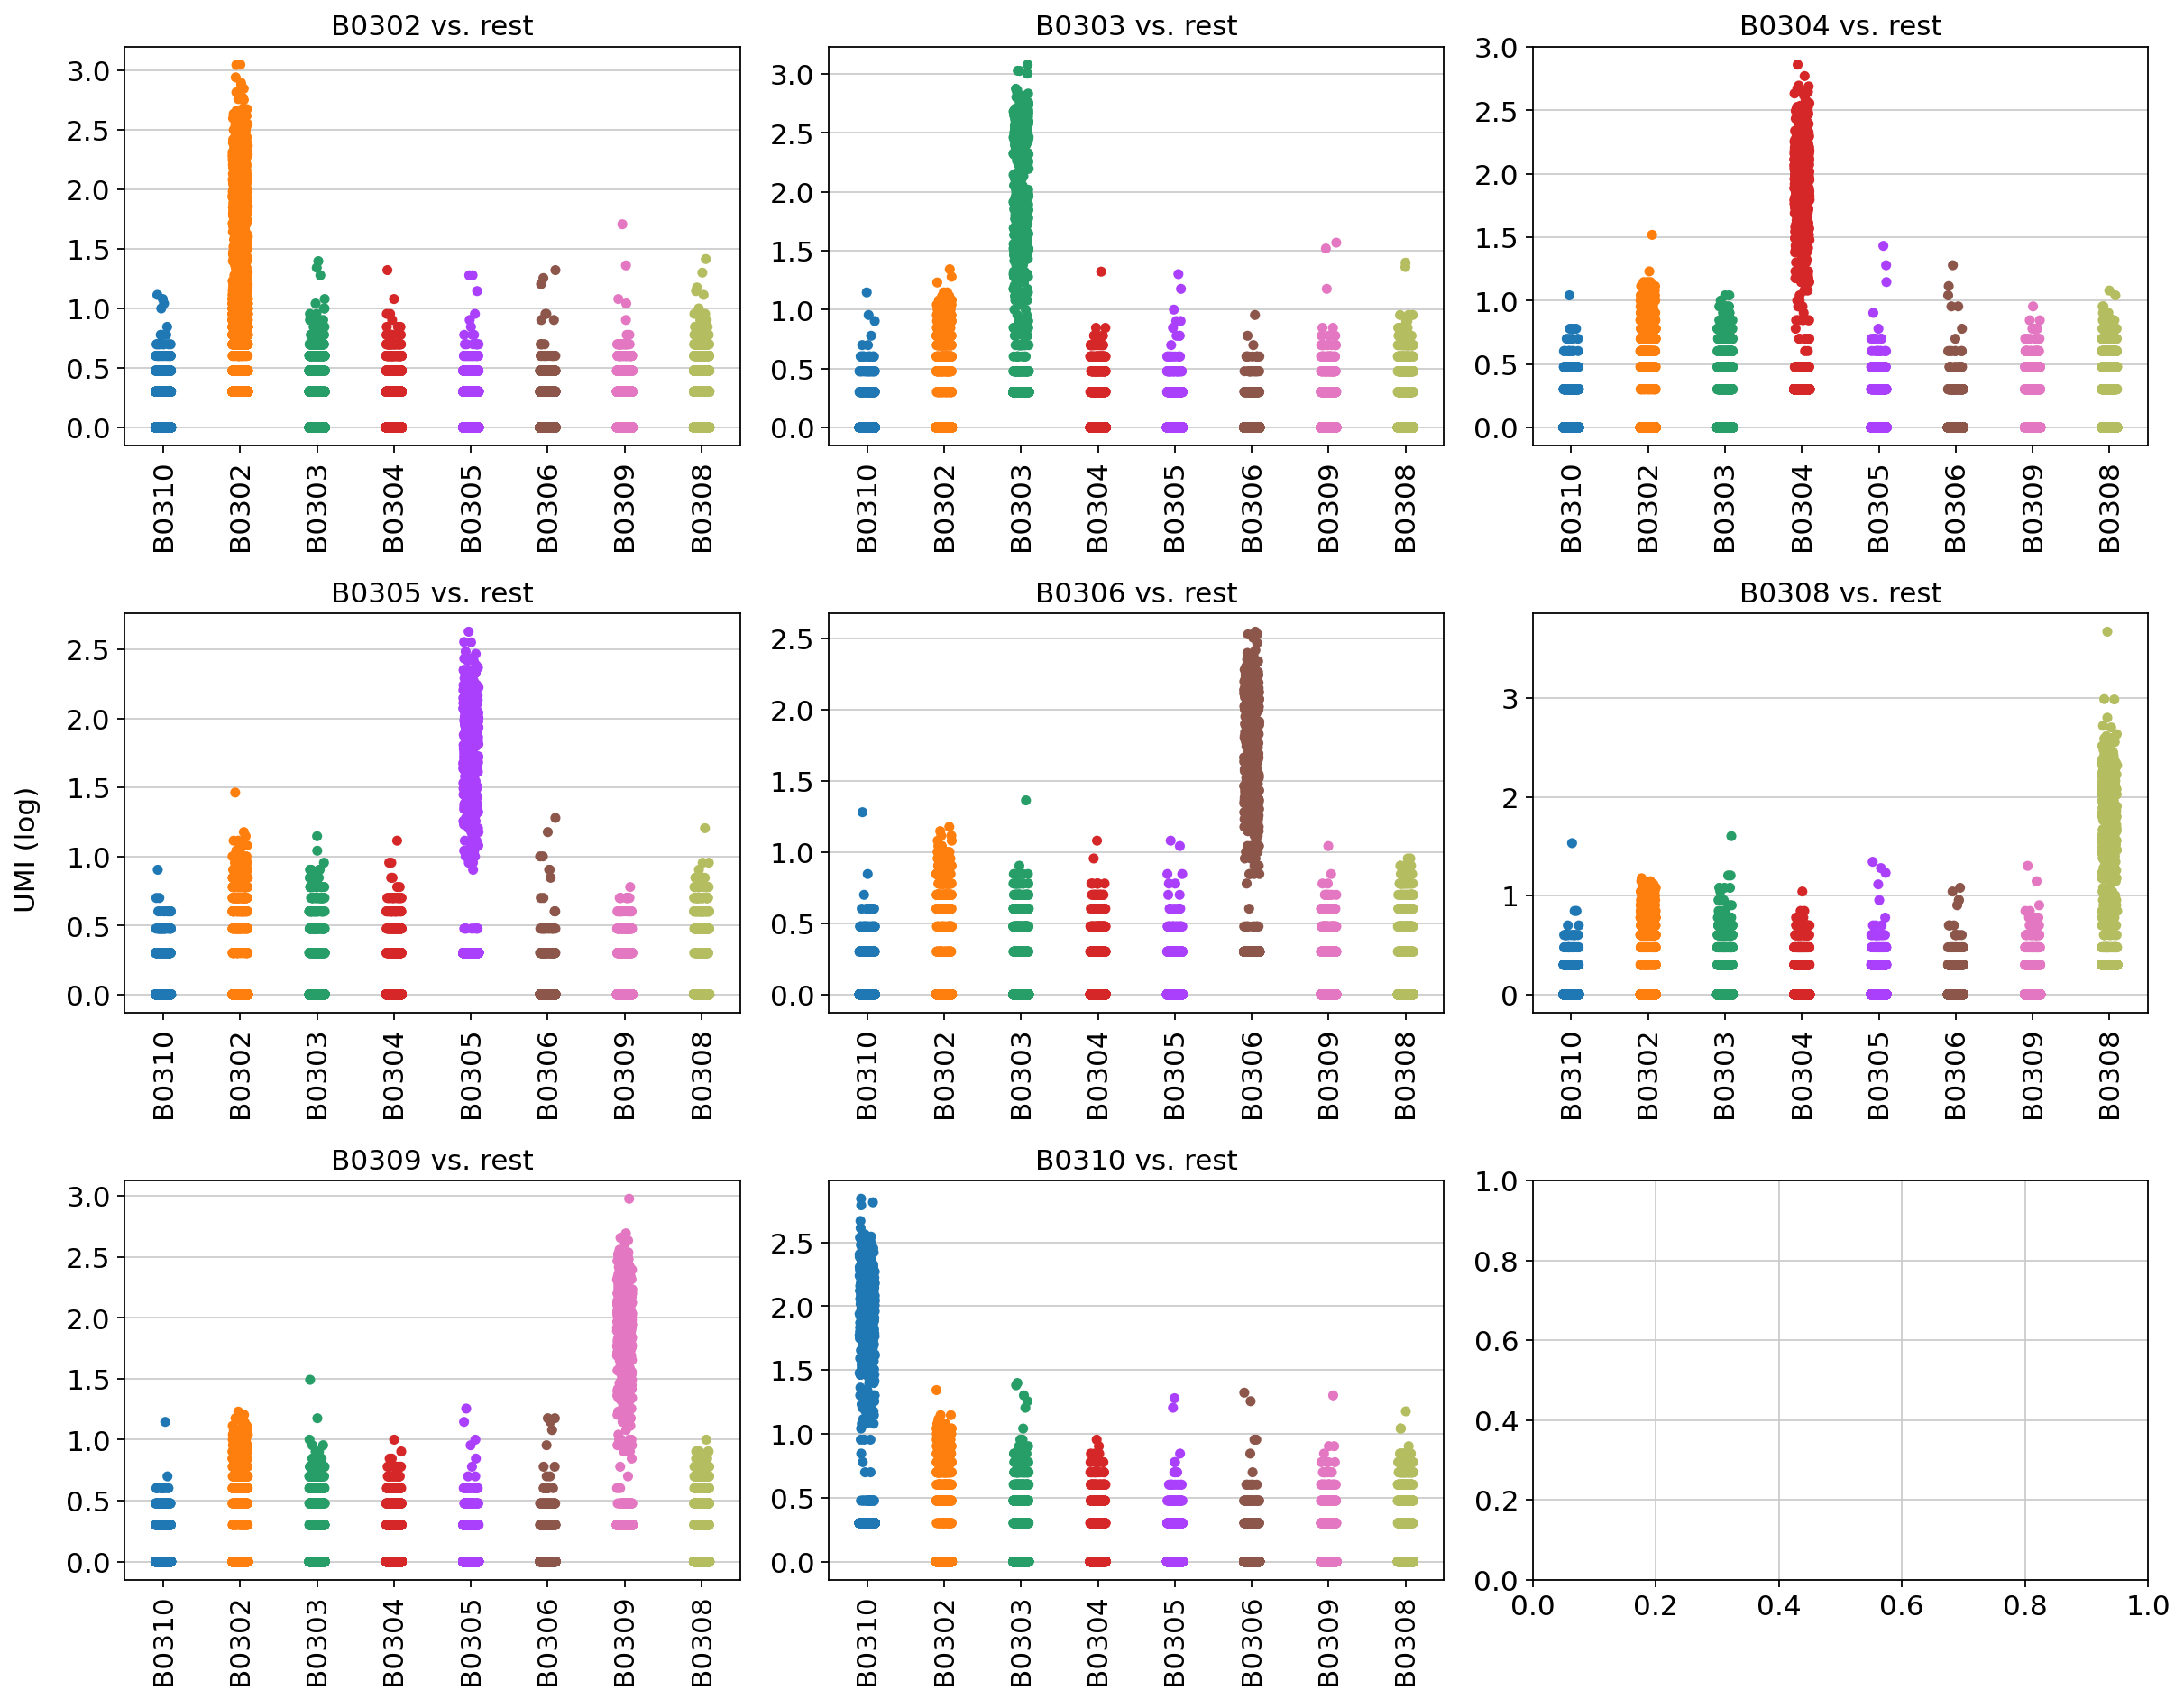

In [65]:
num_hashtags = len(adata.var_names)
num_cols = 3
num_rows = math.ceil(num_hashtags / num_cols)

fig, axes = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(15, num_rows * 4), facecolor="white")
axes = np.ravel(axes)

for idx, hashtag in enumerate(sorted(hashtags)):

    ax = axes[idx]

    df_tmp = adata[adata.obs["hash_id"] == hashtag].to_df()
    df_tmp.columns = df_tmp.columns.str.split("-").str[0]

    sns.stripplot(data=np.log10(df_tmp + 1), ax=ax)

    ax.set_title(f"{hashtag} vs. rest")
    ax.tick_params(axis="x", rotation=90)

fig.text(-0.01, 0.5, "UMI (log)", va='center', rotation='vertical')
plt.tight_layout()
plt.show()

### 25th Percentile

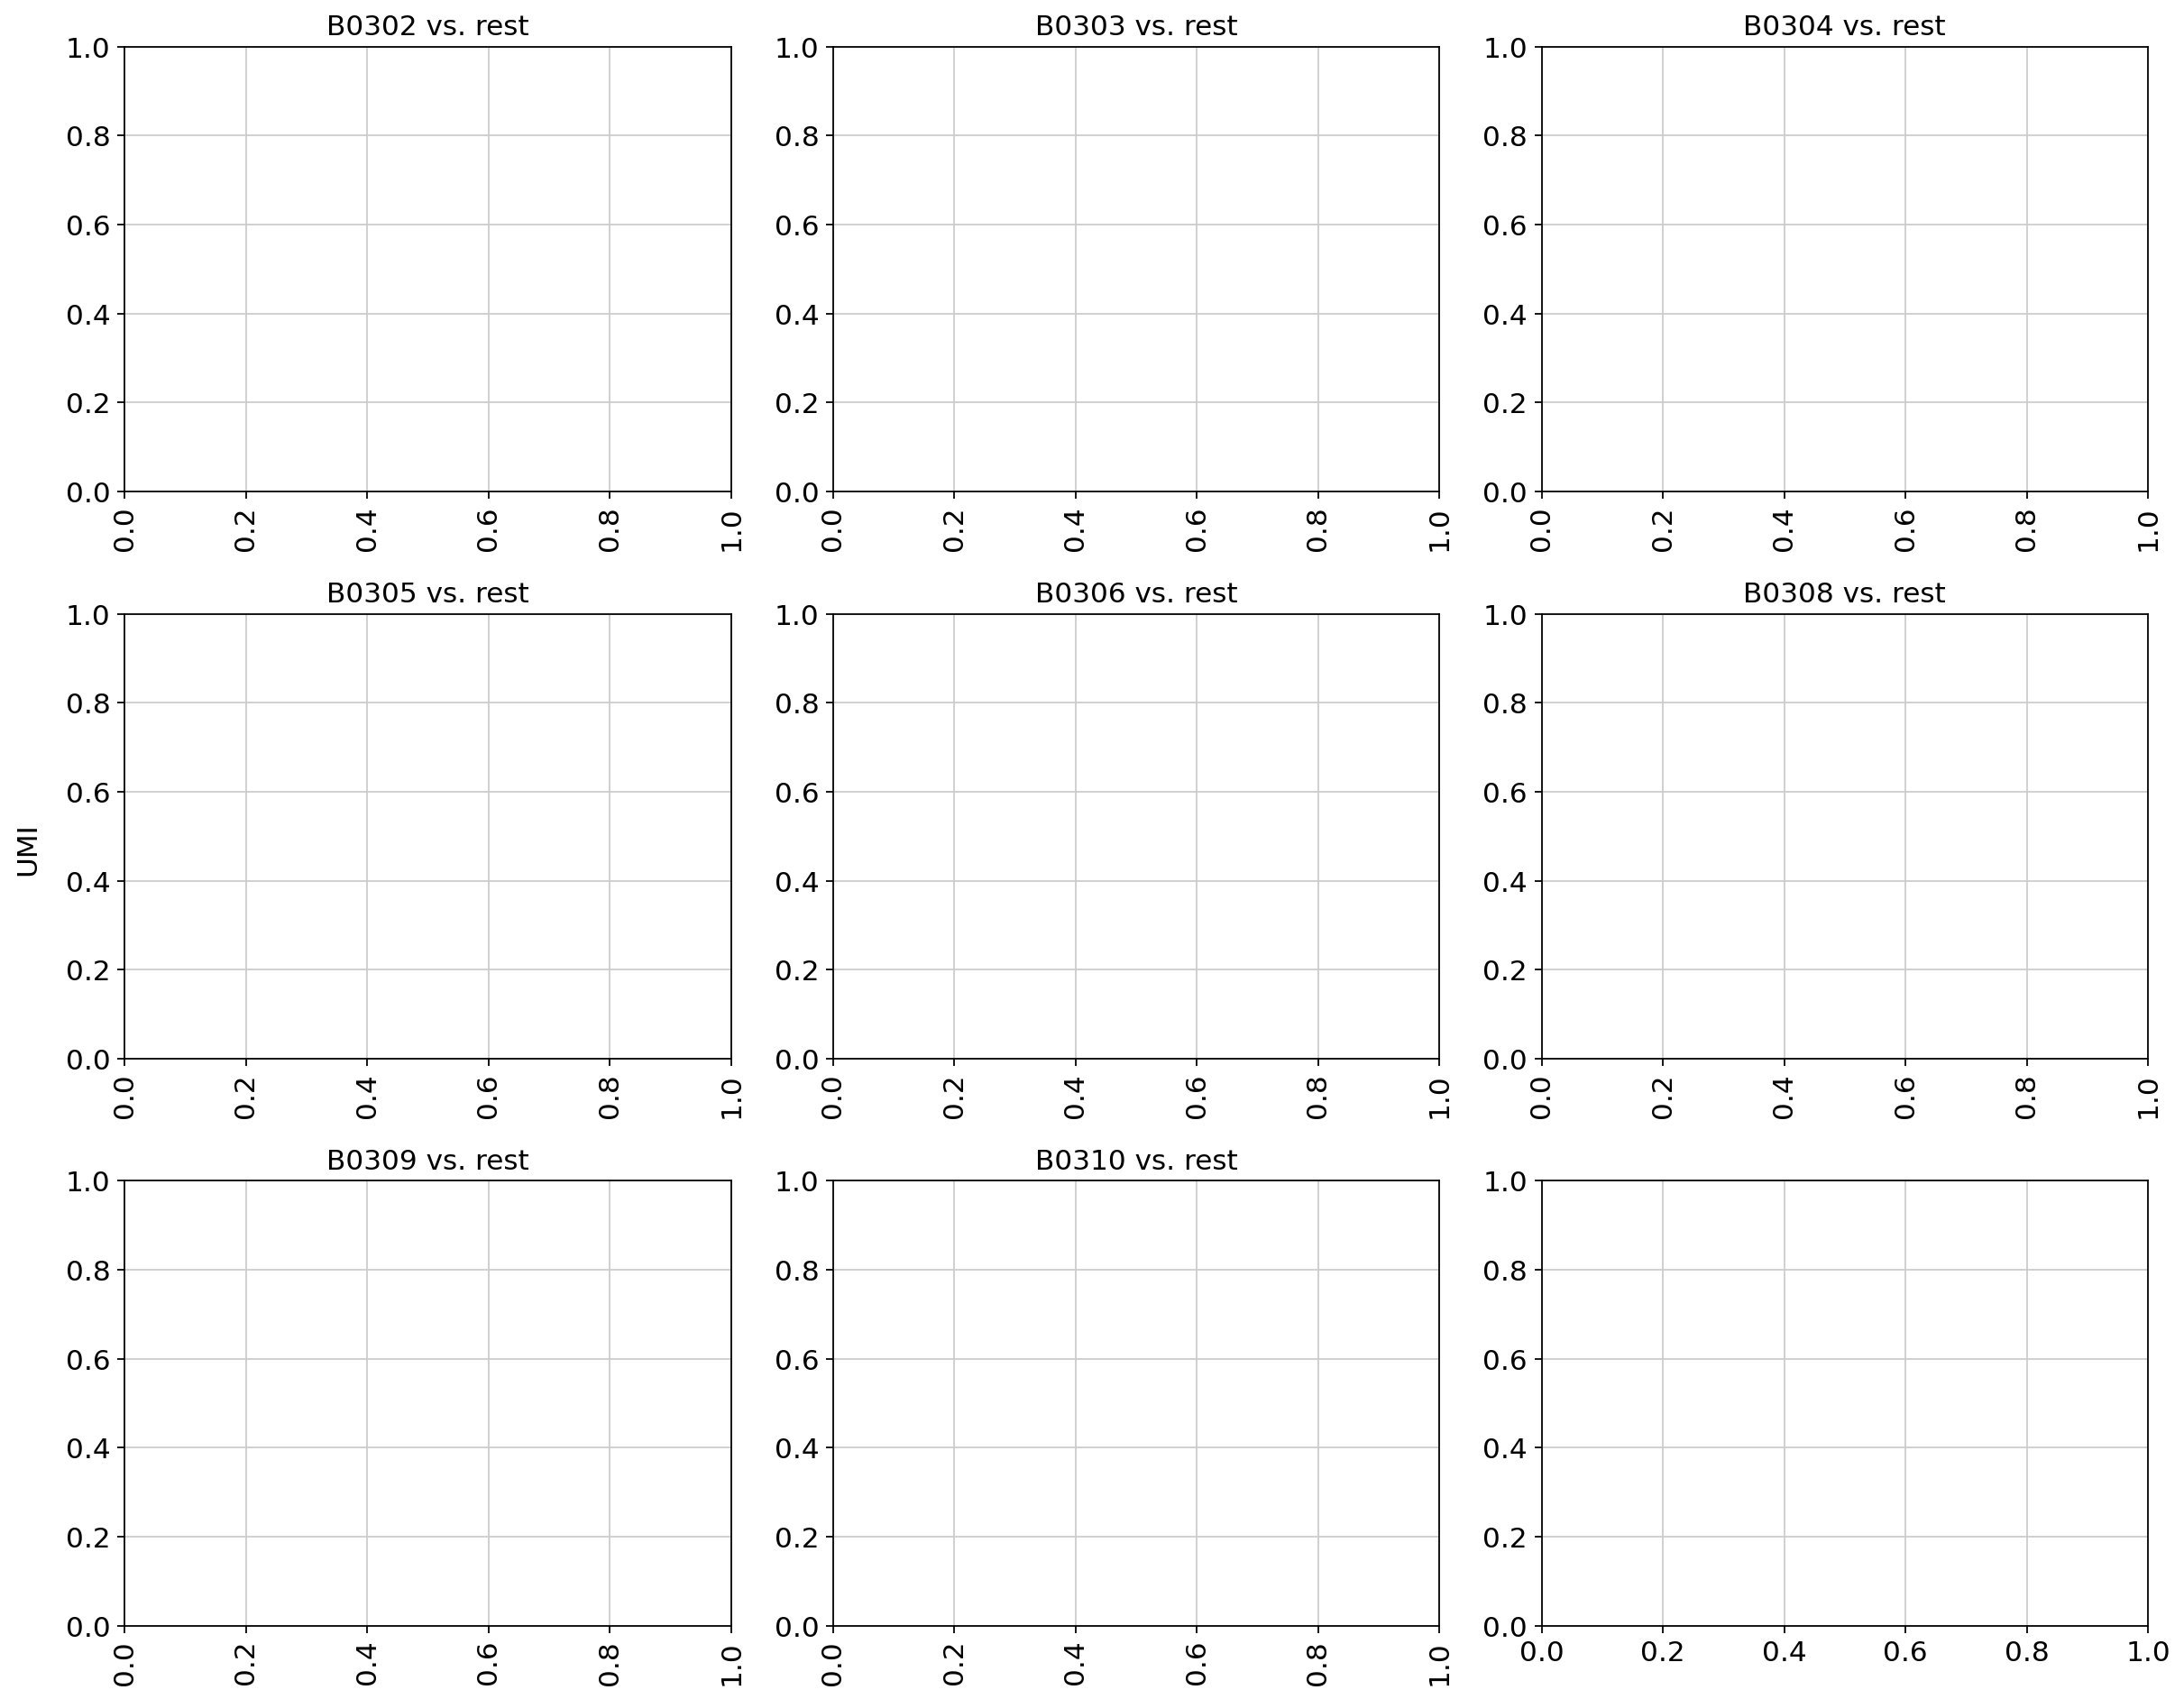

In [66]:
umi_sum_percentile_25 = adata.obs["total_umis"].describe()["25%"]
num_hashtags = len(adata.var_names)
num_cols = 3
num_rows = math.ceil(num_hashtags / num_cols)

fig, axes = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(15, num_rows * 4), facecolor="white")
axes = np.ravel(axes)

for idx, hashtag in enumerate(sorted(hashtags)):

    ax = axes[idx]

    df_tmp = adata[ (adata.obs["total_umis"] < umi_sum_percentile_25) & (adata.obs["hash_id"] == hashtag) ].to_df()
    df_tmp.columns = df_tmp.columns.str.split("-").str[0]

    sns.stripplot(data=df_tmp, ax=ax)

    ax.set_title(f"{hashtag} vs. rest")
    ax.tick_params(axis="x", rotation=90)

fig.text(-0.01, 0.5, "UMI", va='center', rotation='vertical')
plt.tight_layout()
plt.show()

### Singlets

In [70]:
mask_singlet = (adata.obs["hash_id"] != "Doublet") & (adata.obs["hash_id"] != "Negative")
print(f"Cells with singlet classification: {mask_singlet.sum()} ({mask_singlet.mean():.1%})")
print(f"Number of singlets with less than 10 UMIs: {humanfriendly.format_number(adata[mask_singlet & (adata.obs["total_umis"] < 10)].shape[0])}")
print(f"Number of singlets with less than 100 UMIs: {humanfriendly.format_number(adata[mask_singlet & (adata.obs["total_umis"] < 100)].shape[0])}")
print(f"Number of singlets with more than 1000 UMIs: {humanfriendly.format_number(adata[mask_singlet & (adata.obs["total_umis"] > 1000)].shape[0])}")

Cells with singlet classification: 84241 (1.2%)
Number of singlets with less than 10 UMIs: 78,451
Number of singlets with less than 100 UMIs: 82,445
Number of singlets with more than 1000 UMIs: 8


### Doublets

In [71]:
mask_doublet = adata.obs["hash_id"] == "Doublet"
print(f"Cells with doublet classification: {mask_doublet.sum()} ({mask_doublet.mean():.1%})")
print(f"Number doublets with less than 10 umis: {humanfriendly.format_number(adata[mask_doublet & (adata.obs["total_umis"] < 10)].shape[0])}")
print(f"Number doublets with more than 10 umis: {humanfriendly.format_number(adata[mask_doublet & (adata.obs["total_umis"] >= 10)].shape[0])}")

Cells with doublet classification: 22317 (0.3%)
Number doublets with less than 10 umis: 10,873
Number doublets with more than 10 umis: 11,444


## Write adata to Disk

In [90]:
adata

AnnData object with n_obs × n_vars = 10957 × 7
    obs: 'unmapped', 'barcode_sequence', 'hash_id', 'unmapped_reads', 'total_reads', 'total_umis', 'leiden'
    var: 'feature_name', 'total_reads'
    uns: 'log1p', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'hash_id_colors'
    obsm: 'X_umap'
    layers: 'reads'
    obsp: 'distances', 'connectivities'

In [91]:
adata.write(os.path.join(path_outdir, f"{sample_name}.QC.h5ad"))